# Import Libraries

In [6]:
# pip install shap

In [7]:
# pip install xgboost

In [8]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Explainability
import shap

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [9]:
df = pd.read_csv("student_performance_updated_1000.csv")

df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


# Data Cleaning

### Drop useless columns

In [10]:
df = df.drop(columns=["StudentID", "Name"])

### Fix duplicate columns

In [11]:
# Keep consistent columns
df = df.drop(columns=["Study Hours", "Attendance (%)"])

df.rename(columns={
    "StudyHoursPerWeek": "StudyHours",
    "AttendanceRate": "Attendance"
}, inplace=True)

### Check missing values

In [12]:
df.isnull().sum()

Gender                       48
Attendance                   40
StudyHours                   50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Online Classes Taken         25
dtype: int64

In [13]:
df = df.dropna()

In [14]:
df.isnull().sum()

Gender                       0
Attendance                   0
StudyHours                   0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
FinalGrade                   0
Online Classes Taken         0
dtype: int64

# EDA (Exploratory Data Analysis)

### Basic Overview

In [15]:
# Dataset shape
print(df.shape)

# Data types
print(df.dtypes)

# Summary statistics
df.describe()

(743, 8)
Gender                        object
Attendance                   float64
StudyHours                   float64
PreviousGrade                float64
ExtracurricularActivities    float64
ParentalSupport               object
FinalGrade                   float64
Online Classes Taken          object
dtype: object


,Attendance,StudyHours,PreviousGrade,ExtracurricularActivities,FinalGrade
count,743.000000,743.000000,743.000000,743.000000,743.000000
mean,85.427995,17.706595,77.662180,1.526245,80.025572
std,7.304127,6.374228,10.116851,1.036554,9.493118
min,70.000000,8.000000,60.000000,0.000000,62.000000
25%,82.000000,12.000000,70.000000,1.000000,72.000000
50%,85.000000,18.000000,78.000000,2.000000,80.000000
75%,91.000000,22.000000,86.000000,2.000000,88.000000
max,95.000000,30.000000,90.000000,3.000000,92.000000


# Encode Categorical Variables

In [16]:
le = LabelEncoder()

categorical_cols = [
    "Gender",
    "ExtracurricularActivities",
    "ParentalSupport"
]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Convert Target Variable

In [17]:
def grade_category(grade):
    if grade >= 75:
        return "High"
    elif grade >= 50:
        return "Medium"
    else:
        return "Low"

df["Performance"] = df["FinalGrade"].apply(grade_category)

df.drop("FinalGrade", axis=1, inplace=True)

### Encode target

In [18]:
df["Performance"] = le.fit_transform(df["Performance"])

# Feature & Target Split

In [19]:
X = df.drop("Performance", axis=1)
y = df["Performance"]

# Train-Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling

In [21]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Models

## Decision Tree

In [22]:
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

## Random Forest

In [23]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Logistic Regression

In [24]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## Support Vector Machine (SVM)

In [25]:
svm = SVC(probability=True)   # probability=True needed for predict_proba
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

## XGBoost

In [26]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

# Evaluation

## Accuracy

In [27]:
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("SVM:", accuracy_score(y_test, y_pred_svm))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))

Decision Tree: 0.6778523489932886
Random Forest: 0.6778523489932886
SVM: 0.697986577181208
XGBoost: 0.6174496644295302
Logistic Regression: 0.697986577181208


## Confusion Matrix

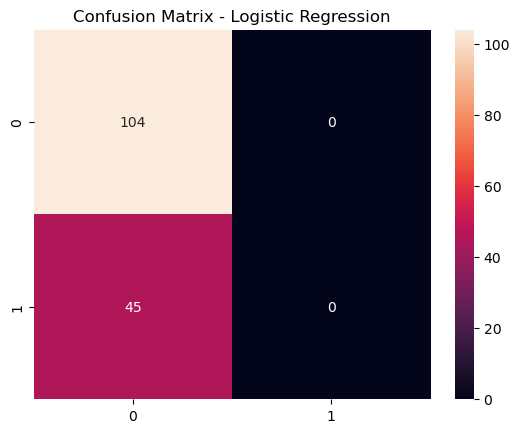

In [28]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Classification Report

In [29]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.70      1.00      0.82       104
           1       0.00      0.00      0.00        45

    accuracy                           0.70       149
   macro avg       0.35      0.50      0.41       149
weighted avg       0.49      0.70      0.57       149



# Model Selection

In [30]:
final_model = lr

# Explainable AI (SHAP)

In [31]:
explainer = shap.Explainer(final_model, X_train)
shap_values = explainer(X_test)

## SHAP Summary Plot

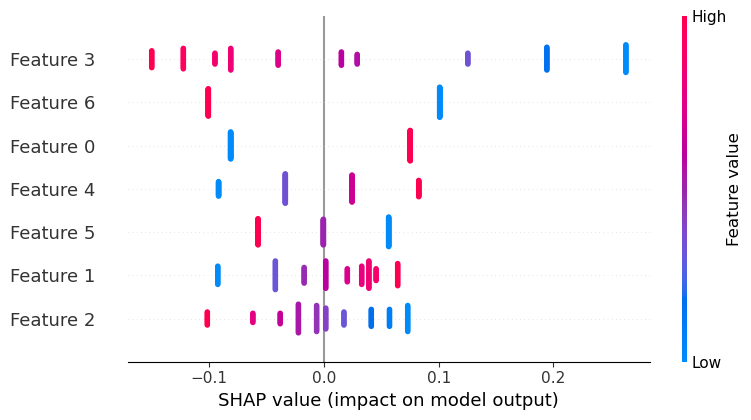

In [32]:
shap.summary_plot(shap_values, X_test)

# Save Model

In [33]:
import joblib

joblib.dump(final_model, "student_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

# Streamlit App

In [34]:
import streamlit as st
import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# ==============================
# LOAD MODEL
# ==============================
model = joblib.load("student_model.pkl")
scaler = joblib.load("scaler.pkl")

# ==============================
# PAGE CONFIG
# ==============================
st.set_page_config(page_title="Student Performance Predictor", layout="centered")

st.title("🎓 Student Performance Predictor")
st.write("Predict student performance and understand influencing factors")

# ==============================
# USER INPUTS
# ==============================

st.subheader("📥 Enter Student Details")

gender = st.selectbox("Gender", ["Male", "Female"])
study_hours = st.slider("Study Hours per Week", 0, 20, 5)
attendance = st.slider("Attendance (%)", 0, 100, 75)
previous_grade = st.slider("Previous Grade", 0, 100, 60)
activities = st.selectbox("Extracurricular Activities", ["Yes", "No"])
parent_support = st.selectbox("Parental Support", ["Low", "Medium", "High"])

# ==============================
# ENCODING INPUTS
# ==============================

gender = 1 if gender == "Male" else 0
activities = 1 if activities == "Yes" else 0

parent_map = {"Low": 0, "Medium": 1, "High": 2}
parent_support = parent_map[parent_support]

# Create dataframe (IMPORTANT for SHAP)
input_data = pd.DataFrame([[
    gender,
    attendance,
    study_hours,
    previous_grade,
    activities,
    parent_support
]], columns=[
    "Gender",
    "Attendance",
    "StudyHours",
    "PreviousGrade",
    "ExtracurricularActivities",
    "ParentalSupport"
])

# ==============================
# PREDICTION
# ==============================

if st.button("🔍 Predict Performance"):

    # Scale input
    scaled_data = scaler.transform(input_data)

    # Prediction
    prediction = model.predict(scaled_data)[0]
    probability = model.predict_proba(scaled_data)

    # Decode label
    label_map = {0: "Low", 1: "Medium", 2: "High"}
    result = label_map[prediction]

    # ==============================
    # OUTPUT
    # ==============================

    st.subheader("📊 Prediction Result")
    st.success(f"Performance Level: {result}")

    st.write("### 🔢 Prediction Probability")
    st.write({
        "Low": round(probability[0][0], 2),
        "Medium": round(probability[0][1], 2),
        "High": round(probability[0][2], 2)
    })

    # ==============================
    # SHAP EXPLANATION
    # ==============================

    st.subheader("🧠 Model Explanation (SHAP)")

    explainer = shap.Explainer(model, input_data)
    shap_values = explainer(input_data)

    fig, ax = plt.subplots()
    shap.plots.waterfall(shap_values[0], show=False)
    st.pyplot(fig)

2026-04-14 22:55:07.401 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 22:55:07.402 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 22:55:07.747 
  command:

    streamlit run C:\Users\Acer\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-04-14 22:55:07.747 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 22:55:07.748 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 22:55:07.748 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 22:55:07.749 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runni

# Visualization

### Distribution of Target Variable

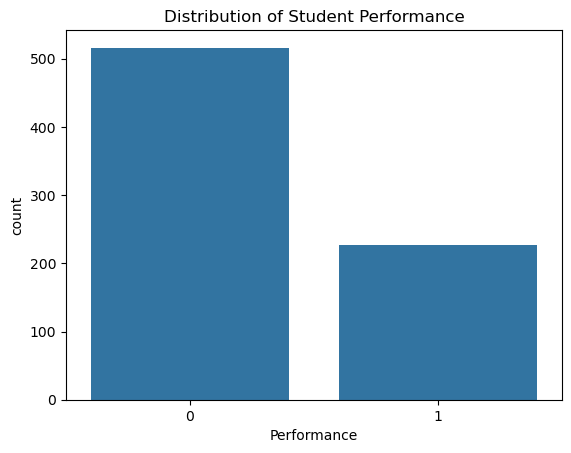

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Performance', data=df)
plt.title("Distribution of Student Performance")
plt.show()

### Performance Distribution

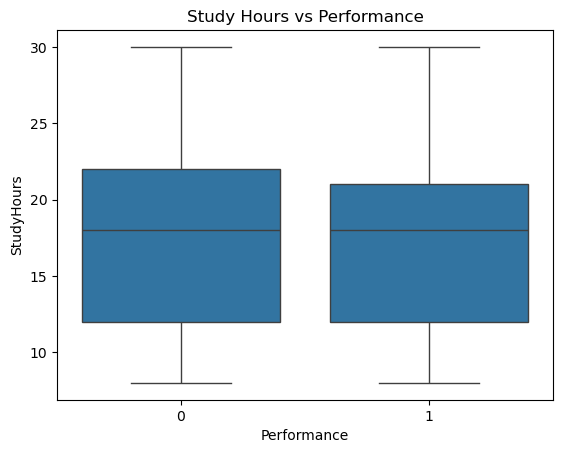

In [37]:
sns.boxplot(x='Performance', y='StudyHours', data=df)
plt.title("Study Hours vs Performance")
plt.show()

### Study Behavior Impact

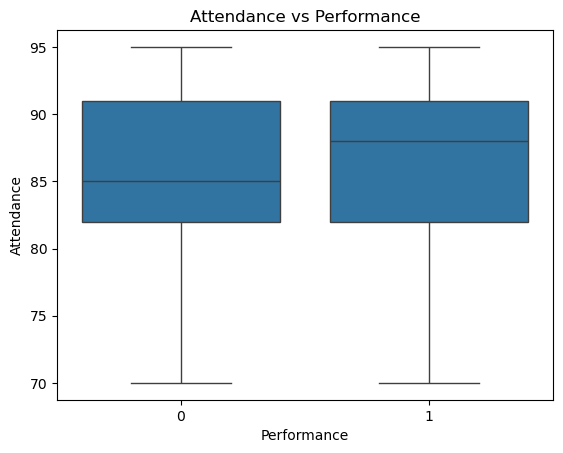

In [38]:
sns.boxplot(x='Performance', y='Attendance', data=df)
plt.title("Attendance vs Performance")
plt.show()

## Correlation Heatmap

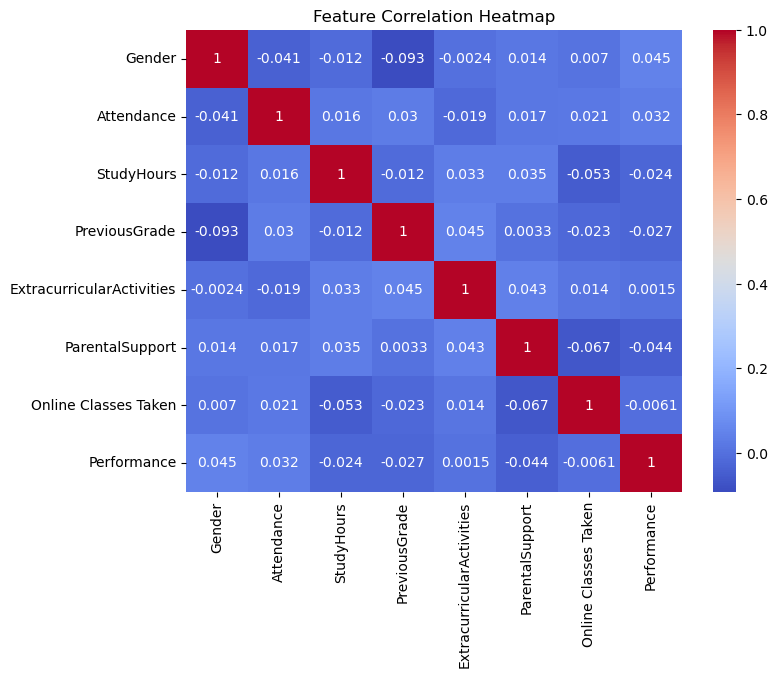

In [39]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()